[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opherdonchin/ModelsOfTheMotorSystems/blob/master/In%20class%20exercises/Ex7_Interaction_torques_true_dynamics.ipynb)


# Lecture 7 In-Class Assignment: Interaction Torques and Internal Models

In this version of the exercise, the arm plant uses the full inertial equations for a two-link planar arm. The controller, however, has only a simplified inverse model: it can add velocity-dependent interaction-torque corrections using a small matrix `B`.

By the end of the notebook you should be able to:
- See why an independent-joint controller fails for a coupled two-joint arm.
- Guess a useful simplified interaction-torque matrix by hand.
- Write a learning rule that improves the controller's simplified inverse model over repeated reaches.
- Compare the hand-guessed and learned interaction-torque corrections with the true interaction torques generated by the plant.

Sections:
1. [Imports & Setup](#section1)
2. [Arm, Task, and Minimum Jerk Trajectory](#section2)
3. [True Two-Link Arm Dynamics](#section3)
4. [Controller's Simplified Inverse Model](#section4)
5. [Baseline: No Interaction-Torque Model](#section5)
6. [Part A: Hand-Guess the B Matrix](#section6)
7. [Part B: Learn the B Matrix](#section7)
8. [Compare Guessed, Learned, and True Interaction Torques](#section8)
9. [Discussion](#section9)

Cells marked **STUDENT CODE HERE** are the places to complete the exercise.


<a id="section1"></a>
## 1. Imports & Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


<a id="section2"></a>
## 2. Arm, Task, and Minimum Jerk Trajectory

The desired hand path is a vertical minimum jerk reach. The dotted curves in later plots show the desired minimum jerk position and velocity profiles.


In [2]:
# Segment parameters: approximate adult upper arm and forearm values.
m1 = 1.5       # upper-arm mass (kg)
m2 = 0.5       # forearm/hand mass (kg)
l1 = 0.30      # upper-arm length (m)
l2 = 0.25      # forearm/hand length (m)
lc1 = 0.15     # upper-arm center of mass from shoulder (m)
lc2 = 0.125    # forearm/hand center of mass from elbow (m)
I1 = (1 / 12) * m1 * l1**2  # upper-arm inertia about its center of mass
I2 = (1 / 12) * m2 * l2**2  # forearm inertia about its center of mass

# Simulation parameters
dt = 0.005
sim_time = 2.0
time = np.arange(0, sim_time, dt)

# Reaching task
start_position = np.array([0.20, 0.10])
end_position = np.array([0.20, 0.30])


In [3]:
def minimum_jerk_profile(start, end, time):
    """Return minimum jerk position and velocity from start to end."""
    T = time[-1]
    s = time / T
    position_blend = 10 * s**3 - 15 * s**4 + 6 * s**5
    velocity_blend = (30 * s**2 - 60 * s**3 + 30 * s**4) / T
    position = start + (end - start) * position_blend
    velocity = (end - start) * velocity_blend
    return position, velocity


def inverse_kinematics(x, y, l1, l2):
    """Compute elbow-up shoulder and elbow angles for Cartesian positions."""
    cos_angle = (x**2 + y**2 - l1**2 - l2**2) / (2 * l1 * l2)
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    sin_angle = np.sqrt(1 - cos_angle**2)
    theta2 = np.arctan2(sin_angle, cos_angle)

    k1 = l1 + l2 * cos_angle
    k2 = l2 * sin_angle
    theta1 = np.arctan2(y, x) - np.arctan2(k2, k1)
    return theta1, theta2


def forward_kinematics(theta1, theta2, l1, l2):
    """Compute hand position from shoulder and elbow angles."""
    x = l1 * np.cos(theta1) + l2 * np.cos(theta1 + theta2)
    y = l1 * np.sin(theta1) + l2 * np.sin(theta1 + theta2)
    return x, y


x_desired, x_velocity_desired = minimum_jerk_profile(start_position[0], end_position[0], time)
y_desired, y_velocity_desired = minimum_jerk_profile(start_position[1], end_position[1], time)

theta1_desired, theta2_desired = inverse_kinematics(x_desired, y_desired, l1, l2)
q_desired = np.vstack((theta1_desired, theta2_desired))
qdot_desired = np.gradient(q_desired, dt, axis=1)
qddot_desired = np.gradient(qdot_desired, dt, axis=1)


<a id="section3"></a>
## 3. True Two-Link Arm Dynamics

The plant uses the standard inertial dynamics for a two-link planar arm:

`M(q) q_ddot + C(q, q_dot) = tau`

`M(q)` is the configuration-dependent mass matrix. `C(q, q_dot)` contains Coriolis and centrifugal interaction torques. These terms are the true dynamics of the simulated arm; they are not represented as a fixed `B` matrix.


In [4]:
def mass_matrix(q):
    """Return the two-link arm mass matrix M(q)."""
    theta2 = q[1]
    c2 = np.cos(theta2)

    M11 = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * c2)
    M12 = I2 + m2 * (lc2**2 + l1 * lc2 * c2)
    M22 = I2 + m2 * lc2**2

    return np.array([[M11, M12],
                     [M12, M22]])


def interaction_torque_true(q, qdot):
    """Return Coriolis and centrifugal interaction torques for the true plant."""
    theta2 = q[1]
    theta1_dot, theta2_dot = qdot
    h = m2 * l1 * lc2 * np.sin(theta2)

    c1 = -h * (2 * theta1_dot * theta2_dot + theta2_dot**2)
    c2 = h * theta1_dot**2
    return np.array([c1, c2])


def arm_forward_dynamics(q, qdot, tau):
    """Compute q_ddot from true two-link arm dynamics."""
    M = mass_matrix(q)
    C = interaction_torque_true(q, qdot)
    return np.linalg.solve(M, tau - C)


def inverse_dynamics_true(q, qdot, qddot):
    """Compute the torque required by the true plant for a desired acceleration."""
    return mass_matrix(q) @ qddot + interaction_torque_true(q, qdot)


The controller's baseline feedforward command treats the two joints as if they were independent. It uses only the diagonal inertia at the starting posture and ignores the nonlinear interaction torques.


In [5]:
M_start = mass_matrix(q_desired[:, 0])
independent_joint_inertia = np.diag(M_start)

tau_independent = independent_joint_inertia[:, None] * qddot_desired


<a id="section4"></a>
## 4. Controller's Simplified Inverse Model

The controller does not have access to the full plant equations. It can only add a simplified velocity-dependent correction:

`tau_correction = B @ q_dot`

Only the off-diagonal terms are used, because the goal is to model interaction torques between joints.


In [6]:
def inverse_model_torque(qdot, B):
    """Compute the controller's simplified interaction-torque correction."""
    B = np.array(B, dtype=float).copy()
    B[0, 0] = 0.0
    B[1, 1] = 0.0
    return B @ qdot


def simulate_reach(B_controller):
    """Simulate one reach through the true plant using the simplified controller model."""
    B_controller = np.array(B_controller, dtype=float).copy()
    B_controller[0, 0] = B_controller[1, 1] = 0.0

    q = q_desired[:, 0].astype(float).copy()
    qdot = np.array([0.0, 0.0])

    q_history = np.zeros((2, len(time)))
    qdot_history = np.zeros((2, len(time)))
    correction_history = np.zeros((2, len(time)))
    true_interaction_history = np.zeros((2, len(time)))
    q_history[:, 0] = q
    qdot_history[:, 0] = qdot

    for k in range(1, len(time)):
        tau_correction = inverse_model_torque(qdot, B_controller)
        tau = tau_independent[:, k - 1] + tau_correction
        qddot = arm_forward_dynamics(q, qdot, tau)

        qdot = qdot + qddot * dt
        q = q + qdot * dt

        q_history[:, k] = q
        qdot_history[:, k] = qdot
        correction_history[:, k] = tau_correction
        true_interaction_history[:, k] = interaction_torque_true(q, qdot)

    x_actual, y_actual = forward_kinematics(q_history[0], q_history[1], l1, l2)

    return {
        "B": B_controller,
        "theta1": q_history[0],
        "theta2": q_history[1],
        "theta1_dot": qdot_history[0],
        "theta2_dot": qdot_history[1],
        "x": x_actual,
        "y": y_actual,
        "x_dot": np.gradient(x_actual, dt),
        "y_dot": np.gradient(y_actual, dt),
        "model_correction": correction_history,
        "true_interaction": true_interaction_history,
    }


def movement_summary(result):
    """Return compact error metrics for one simulated reach."""
    path_error = np.sqrt((result["x"] - x_desired)**2 + (result["y"] - y_desired)**2)
    endpoint_error = np.linalg.norm(
        np.array([result["x"][-1], result["y"][-1]]) - end_position
    )
    return {
        "mean_path_error_cm": 100 * np.mean(path_error),
        "endpoint_error_cm": 100 * endpoint_error,
        "max_x_deviation_cm": 100 * np.max(np.abs(result["x"] - x_desired)),
    }


def print_movement_summary(result, label):
    metrics = movement_summary(result)
    print(label)
    print("B =")
    print(result["B"])
    for key, value in metrics.items():
        print(f"{key}: {value:.3f}")


In [7]:
def plot_cartesian_profiles(result, title):
    """Plot actual position and velocity profiles against the minimum jerk target."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
    fig.suptitle(title)
    position_margin_cm = 5.0
    x_limits_cm = (100 * np.min(x_desired) - position_margin_cm,
                   100 * np.max(x_desired) + position_margin_cm)
    y_limits_cm = (100 * np.min(y_desired) - position_margin_cm,
                   100 * np.max(y_desired) + position_margin_cm)
    x_velocity_limits_cm_s = (-10.0, 10.0)
    y_velocity_limits_cm_s = (-5.0, 25.0)

    axes[0, 0].plot(time, 100 * result["x"], label="Actual x", color="tab:blue")
    axes[0, 0].plot(time, 100 * x_desired, ":", label="Minimum jerk x", color="black")
    axes[0, 0].set_ylabel("x position (cm)")
    axes[0, 0].set_ylim(x_limits_cm)

    axes[0, 1].plot(time, 100 * result["y"], label="Actual y", color="tab:green")
    axes[0, 1].plot(time, 100 * y_desired, ":", label="Minimum jerk y", color="black")
    axes[0, 1].set_ylabel("y position (cm)")
    axes[0, 1].set_ylim(y_limits_cm)

    axes[1, 0].plot(time, 100 * result["x_dot"], label="Actual x velocity", color="tab:blue")
    axes[1, 0].plot(time, 100 * x_velocity_desired, ":", label="Minimum jerk x velocity", color="black")
    axes[1, 0].set_xlabel("time (s)")
    axes[1, 0].set_ylabel("x velocity (cm/s)")
    axes[1, 0].set_ylim(x_velocity_limits_cm_s)

    axes[1, 1].plot(time, 100 * result["y_dot"], label="Actual y velocity", color="tab:green")
    axes[1, 1].plot(time, 100 * y_velocity_desired, ":", label="Minimum jerk y velocity", color="black")
    axes[1, 1].set_xlabel("time (s)")
    axes[1, 1].set_ylabel("y velocity (cm/s)")
    axes[1, 1].set_ylim(y_velocity_limits_cm_s)

    for ax in axes.flat:
        ax.legend()

    plt.tight_layout()
    plt.show()


<a id="section5"></a>
## 5. Baseline: No Interaction-Torque Model

First, run the movement with `B_controller = 0`. The plant is a coupled two-link arm, but the controller ignores interaction torques.


No interaction-torque model
B =
[[0. 0.]
 [0. 0.]]
mean_path_error_cm: 1.659
endpoint_error_cm: 4.324
max_x_deviation_cm: 4.462


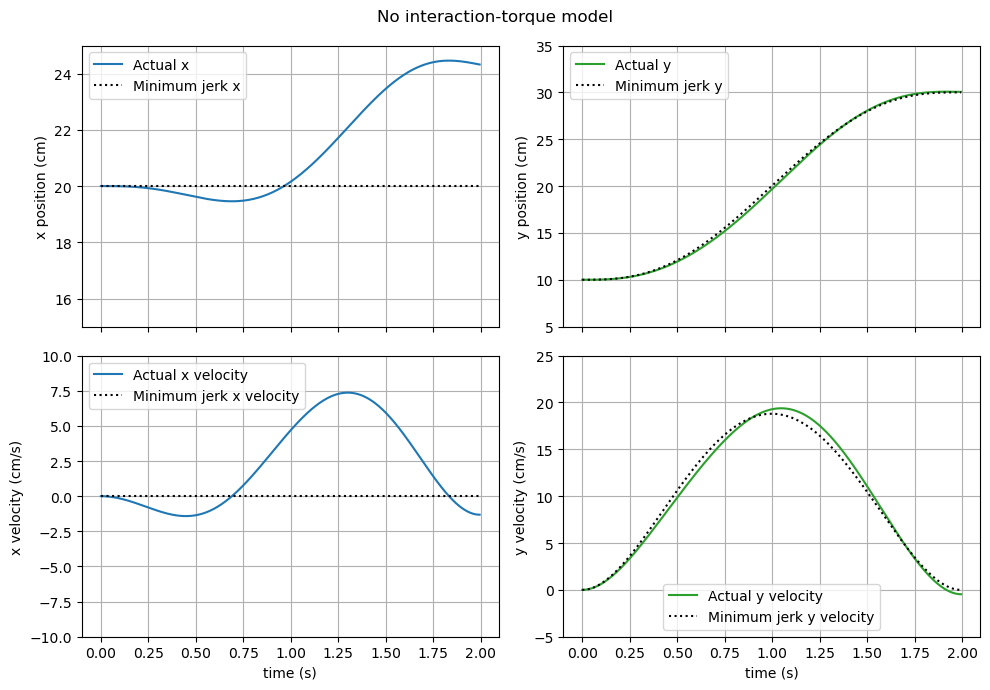

In [8]:
B_none = np.array([[0.0, 0.0],
                   [0.0, 0.0]])

baseline_result = simulate_reach(B_none)
print_movement_summary(baseline_result, "No interaction-torque model")
plot_cartesian_profiles(baseline_result, "No interaction-torque model")


<a id="section6"></a>
## 6. Part A: Hand-Guess the B Matrix

Choose a `B_guess` matrix for the controller's simplified inverse model. The true plant is nonlinear, so there is no single fixed `B` that is exactly correct. Your goal is to find values that make the movement reasonably straight and smooth for this reach.

Try to produce:
- x position that stays close to the desired vertical path.
- y position that follows the minimum jerk curve.
- y velocity that is smooth and bell-shaped.

Start with small off-diagonal values, run the cell, and revise `B_guess` until the profiles look reasonable.


Hand-guessed interaction-torque model
B =
[[0. 0.]
 [0. 0.]]
mean_path_error_cm: 1.659
endpoint_error_cm: 4.324
max_x_deviation_cm: 4.462


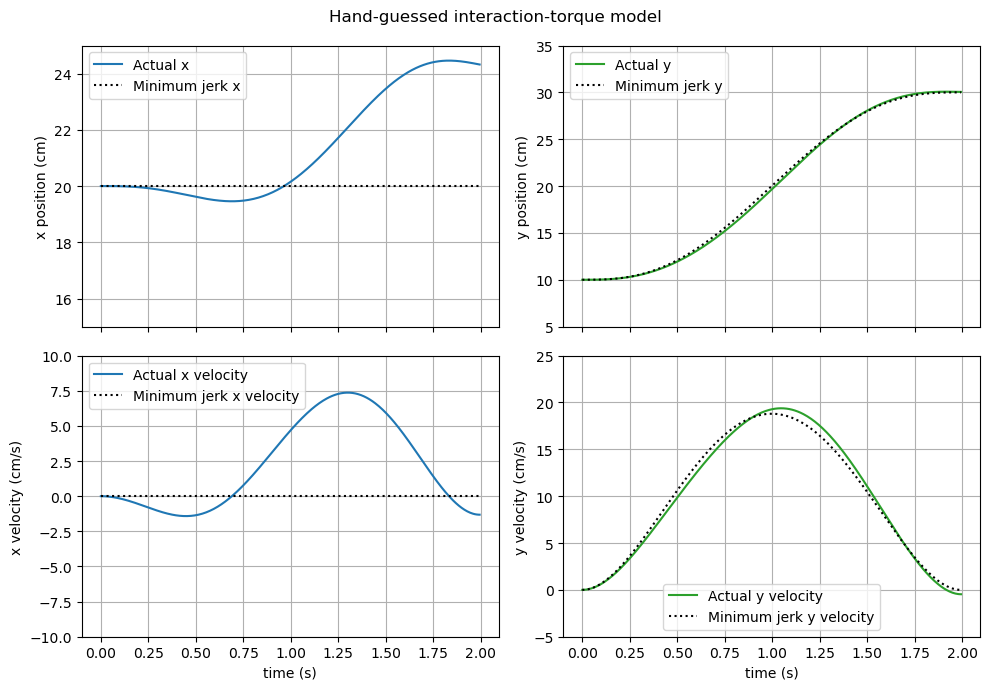

In [9]:
# STUDENT CODE HERE
B_guess = np.array([[0.0, 0.0],
                    [0.0, 0.0]])

guessed_result = simulate_reach(B_guess)
print_movement_summary(guessed_result, "Hand-guessed interaction-torque model")
plot_cartesian_profiles(guessed_result, "Hand-guessed interaction-torque model")


**Questions**:
- Which off-diagonal entry had the clearest effect on the straightness of the hand path?
- Did the same `B` values improve both position and velocity profiles?
- Why might a fixed matrix be only an approximation to the true interaction torques?


<a id="section7"></a>
## 7. Part B: Learn the B Matrix

Now let the controller start with no interaction-torque model. Complete `update_B` so the simplified inverse model improves over repeated reaches.

A useful learning rule should combine a movement error signal with the velocity of the other joint. Keep the diagonal entries at zero.


In [10]:
def update_B(B, result, learning_rate=0.2):
    """Update the simplified inverse-model matrix after one reach."""
    new_B = np.array(B, dtype=float).copy()

    desired_theta = q_desired
    actual_theta = np.vstack((result["theta1"], result["theta2"]))
    theta_error = desired_theta - actual_theta
    theta_dot = np.vstack((result["theta1_dot"], result["theta2_dot"]))

    # STUDENT CODE HERE
    # Hints:
    # - The update for B[0, 1] should use shoulder error and elbow velocity.
    # - The update for B[1, 0] should use elbow error and shoulder velocity.
    # - Summing or averaging across time can turn each trajectory into one update.
    # - Multiplying by learning_rate keeps the update gradual.

    new_B[0, 0] = 0.0
    new_B[1, 1] = 0.0
    return new_B


Learned interaction-torque model
B =
[[0. 0.]
 [0. 0.]]
mean_path_error_cm: 1.659
endpoint_error_cm: 4.324
max_x_deviation_cm: 4.462


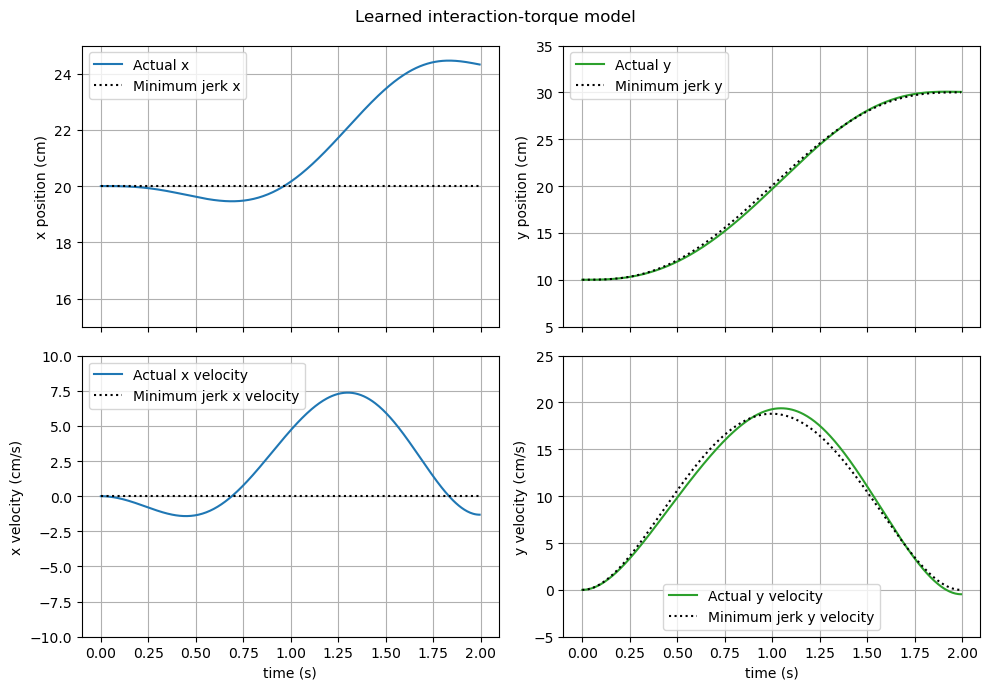

In [11]:
B_learned = np.array([[0.0, 0.0],
                      [0.0, 0.0]])

num_trials = 30
learning_rate = 0.2
history = []

for trial in range(num_trials):
    trial_result = simulate_reach(B_learned)
    metrics = movement_summary(trial_result)
    history.append({
        "trial": trial + 1,
        "B01": B_learned[0, 1],
        "B10": B_learned[1, 0],
        **metrics,
    })
    B_learned = update_B(B_learned, trial_result, learning_rate=learning_rate)

learned_result = simulate_reach(B_learned)
print_movement_summary(learned_result, "Learned interaction-torque model")
plot_cartesian_profiles(learned_result, "Learned interaction-torque model")


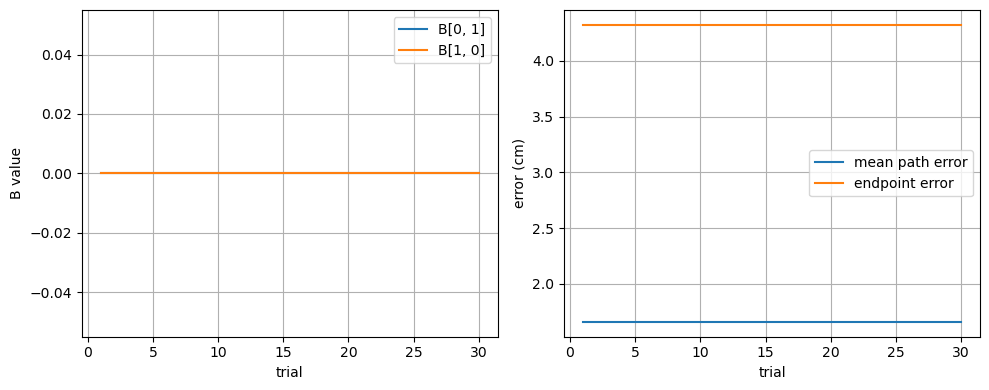

In [12]:
history_array = np.array(
    [[h["trial"], h["B01"], h["B10"], h["mean_path_error_cm"], h["endpoint_error_cm"]] for h in history]
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history_array[:, 0], history_array[:, 1], label="B[0, 1]")
axes[0].plot(history_array[:, 0], history_array[:, 2], label="B[1, 0]")
axes[0].set_xlabel("trial")
axes[0].set_ylabel("B value")
axes[0].legend()

axes[1].plot(history_array[:, 0], history_array[:, 3], label="mean path error")
axes[1].plot(history_array[:, 0], history_array[:, 4], label="endpoint error")
axes[1].set_xlabel("trial")
axes[1].set_ylabel("error (cm)")
axes[1].legend()

plt.tight_layout()
plt.show()


**Questions**:
- What error signal did your learning rule use?
- Did the learned `B` resemble your hand-guessed `B`?
- Did learning improve straightness, endpoint accuracy, velocity shape, or all three?


<a id="section8"></a>
## 8. Compare Guessed, Learned, and True Interaction Torques

After completing Parts A and B, compare the torque corrections produced by your hand-guessed and learned simplified models. The dotted line shows the full torque correction required by the true plant along the desired movement. This includes off-diagonal inertia terms as well as Coriolis and centrifugal interaction torques.


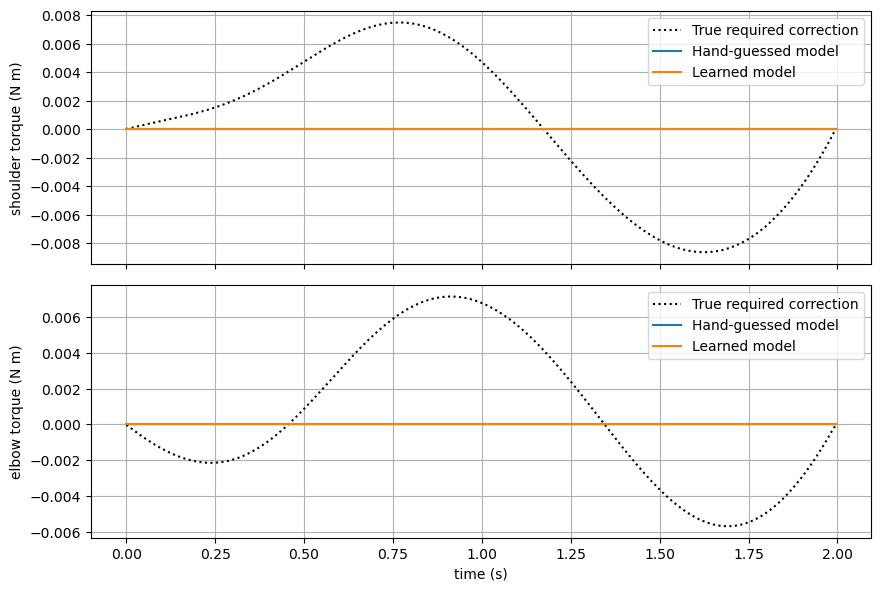

Hand-guessed B:
[[0. 0.]
 [0. 0.]]
Learned B:
[[0. 0.]
 [0. 0.]]


In [13]:
def true_correction_on_desired_trajectory():
    """Compute the full correction needed by the true plant along the desired trajectory."""
    corrections = np.zeros_like(q_desired)
    for k in range(len(time)):
        true_tau = inverse_dynamics_true(q_desired[:, k], qdot_desired[:, k], qddot_desired[:, k])
        corrections[:, k] = true_tau - tau_independent[:, k]
    return corrections


def model_correction_on_desired_trajectory(B):
    """Compute simplified model corrections along the desired trajectory."""
    corrections = np.zeros_like(q_desired)
    for k in range(len(time)):
        corrections[:, k] = inverse_model_torque(qdot_desired[:, k], B)
    return corrections


true_correction_desired = true_correction_on_desired_trajectory()
guessed_correction_desired = model_correction_on_desired_trajectory(B_guess)
learned_correction_desired = model_correction_on_desired_trajectory(B_learned)

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
labels = ["shoulder", "elbow"]

for joint in range(2):
    axes[joint].plot(time, true_correction_desired[joint], ":", color="black", label="True required correction")
    axes[joint].plot(time, guessed_correction_desired[joint], label="Hand-guessed model")
    axes[joint].plot(time, learned_correction_desired[joint], label="Learned model")
    axes[joint].set_ylabel(f"{labels[joint]} torque (N m)")
    axes[joint].legend()

axes[-1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

print("Hand-guessed B:")
print(B_guess)
print("Learned B:")
print(B_learned)


**Questions**:
- Where did the simplified model match the true interaction torque well?
- Where did it fail?
- Did the learned model produce the same torque profile as your hand-guessed model, or did it solve the task in a different way?


<a id="section9"></a>
## 9. Discussion

Please edit this markdown cell to answer the following questions:
- Why does an independent-joint feedforward command fail for a true two-link arm?
- What is the difference between the plant's true dynamics and the controller's simplified inverse model?
- Why might the nervous system use approximate internal models instead of exact equations?
